# Module 4 – Session 2: Practical Exercises

Objective: Calculate and interpret core classification metrics from confusion matrices and via Scikit-learn.


## Exercise 1 – The Metrics Calculator (Conceptual)

Confusion matrix (patients = 100):

- TN = 85 (Actual No Disease predicted No Disease)
- FP = 5  (Actual No Disease predicted Disease)
- FN = 8  (Actual Disease predicted No Disease)
- TP = 2  (Actual Disease predicted Disease)

Calculations:
- Accuracy = (TP + TN) / total = (2 + 85) / 100 = 0.87
- Precision = TP / (TP + FP) = 2 / (2 + 5) ≈ 0.286
- Recall = TP / (TP + FN) = 2 / (2 + 8) = 0.20
- F1 = 2 * (Precision * Recall) / (Precision + Recall) ≈ 2 * (0.286 * 0.20) / (0.486) ≈ 0.235


In [1]:
# Quick check of the above calculations in code
TP, TN, FP, FN = 2, 85, 5, 8
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)
accuracy, precision, recall, f1


(0.87, 0.2857142857142857, 0.2, 0.23529411764705882)

## Exercise 2 – The Scikit-learn Report Card (Coding)

Re-use the logistic regression pipeline from Session 1, then compute classification report, confusion matrix, and ROC/AUC.


              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



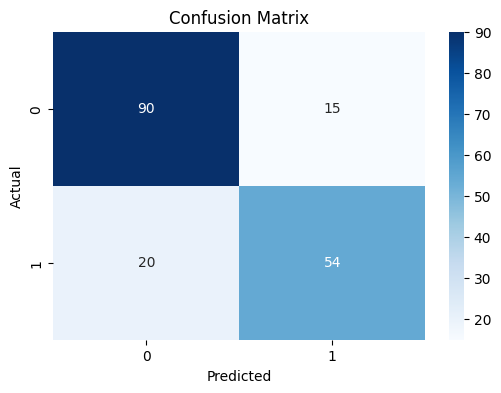

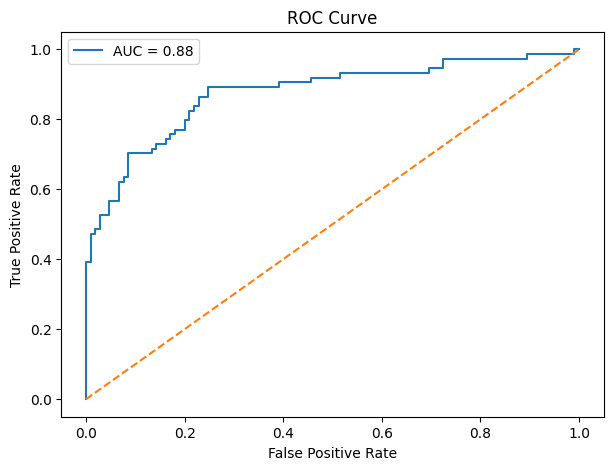

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
)
import matplotlib.pyplot as plt
import seaborn as sns

# Load and preprocess (same as Session 1)
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

cols = ['Survived', 'Pclass', 'Sex', 'Age', 'Fare']
df = df[cols]

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = df.dropna()

X = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)
print(classification_report(y_test, predictions))

# Confusion matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC and AUC
y_pred_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()



After running the cell above, capture the Precision, Recall, and F1-score for class '1' (Survived) from the classification report, and note them here.


## Exercise 3 – The Strategist (Critical Thinking)

- Precision > Recall example: Email spam filtering. Marking a legitimate email as spam (FP) is costly, so we want high precision and can tolerate missing some spam.
- Recall > Precision example: Sepsis early-warning alerts in hospitals. Missing a true sepsis case (FN) is dangerous, so we prefer to catch as many true cases as possible even if it means more false alarms.
